# Bài tập 4 — Gom cụm (Clustering)
### Môn Khai phá dữ liệu — Trường Đại học Giao thông Vận tải TP.HCM
### Nhóm: ......... | Lớp: ......... | Ngày: .........

Notebook này thực hiện Gom cụm trên **2 bộ dữ liệu đã được tiền xử lý ở Bài 1**:

1. **Olist E-Commerce** — gom cụm khách hàng theo đặc trưng RFM
   (`data/processed/olist/olist_clustering.csv`)
2. **Inside Airbnb Listings** — gom cụm listing theo giá/sức chứa/đánh giá/tiện nghi
   (`data/processed/airbnb/airbnb_clustering.csv`)

Với mỗi bộ, notebook thực hiện đầy đủ theo Mục 6 và Mục 7 của đề bài:
- Chuẩn bị dữ liệu (impute, chuẩn hóa) kèm giải trình.
- Áp dụng **2 thuật toán**: K-Means và DBSCAN, nêu rõ giả định mỗi thuật toán.
- Chọn tham số **có phương pháp** (elbow + silhouette cho K-Means; k-distance
  + quét lưới cho DBSCAN), không dùng mặc định mà không giải thích.
- Đánh giá bằng Silhouette score và Davies–Bouldin index.
- Mô tả (profiling) từng cụm ở mức kỹ thuật (diễn giải sâu theo nghiệp vụ
  để dành cho đồ án).



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer

sns.set_style('whitegrid')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)


## 0. Giả định của các thuật toán sử dụng

Áp dụng chung cho cả 2 bộ dữ liệu bên dưới (Mục 7 của đề bài yêu cầu nêu rõ
giả định của mỗi thuật toán bằng ngôn ngữ của nhóm).

### K-Means
- Giả định các cụm có dạng gần **hình cầu (spherical)**, kích thước và mật
  độ tương đồng nhau — vì thuật toán tối ưu theo khoảng cách Euclid tới tâm
  cụm.
- Mỗi điểm bắt buộc thuộc **đúng 1 cụm** (hard assignment), không có khái
  niệm "nhiễu"/outlier.
- Phải **biết trước số cụm k**.
- **Nhạy cảm với thang đo** (đơn vị) của thuộc tính → bắt buộc chuẩn hóa
  trước khi chạy.
- **Nhạy cảm với ngoại lai** vì tối ưu tổng bình phương khoảng cách (SSE).
- Kết quả phụ thuộc điểm khởi tạo tâm cụm → dùng `k-means++` và chạy nhiều
  lần (`n_init`) để giảm rủi ro hội tụ về cực tiểu cục bộ.

### DBSCAN
- Giả định cụm là **vùng có mật độ điểm cao**, được phân tách bởi các vùng
  mật độ thấp — không giả định hình dạng cụm (có thể lồi lõm bất kỳ).
- **Không cần biết trước số cụm**; số cụm là kết quả của thuật toán.
- Có khái niệm **nhiễu (noise, nhãn -1)** rõ ràng — điểm không đủ mật độ lân
  cận sẽ không thuộc cụm nào, hữu ích để phát hiện outlier.
- Phụ thuộc mạnh vào 2 siêu tham số: `eps` (bán kính lân cận) và
  `min_samples` (số điểm tối thiểu để tạo vùng lõi) — chọn sai sẽ khiến toàn
  bộ dữ liệu bị gộp 1 cụm hoặc toàn bộ bị coi là nhiễu.
- Gặp khó khi các cụm trong cùng bộ dữ liệu có **mật độ rất khác nhau**.

### Vì sao không dùng phân cụm phân cấp (hierarchical) ở đây
Phân cụm phân cấp (Agglomerative) mặc định cần ma trận khoảng cách đầy đủ
kích thước n×n. Với quy mô của 2 bộ dữ liệu (Olist ~96 nghìn, Airbnb ~30
nghìn dòng), ma trận này tốn hàng chục GB bộ nhớ — không khả thi chạy trên
máy cá nhân. Nhóm dùng K-Means (nhanh, tuyến tính theo n) và DBSCAN (hiệu
quả nhờ cấu trúc cây tìm lân cận) làm 2 thuật toán so sánh, đúng yêu cầu
"≥ 2 thuật toán" của đề bài.


---
# PHẦN 1 — OLIST: Gom cụm khách hàng theo RFM

Dataset đầu vào: `data/processed/olist/olist_clustering.csv` (xuất từ Bài 1,
đã sạch, không còn missing). Mỗi dòng là 1 khách hàng (`customer_unique_id`)
với 3 đặc trưng:
- `recency_days`: số ngày kể từ lần mua gần nhất tới mốc tham chiếu.
- `frequency`: số đơn hàng đã đặt.
- `monetary`: tổng chi tiêu.

## 1.1 Tải dữ liệu


In [2]:
OLIST_PATH = '../data/processed/olist/olist_clustering.csv'
olist_df = pd.read_csv(OLIST_PATH)
print("Shape:", olist_df.shape)
print(olist_df.dtypes)
olist_df.head()


Shape: (96096, 4)
customer_unique_id        str
recency_days            int64
frequency               int64
monetary              float64
dtype: object


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


## 1.2 Chuẩn bị dữ liệu cho gom cụm

- `frequency` và `monetary` lệch phải rất mạnh (đa số khách hàng chỉ mua 1
  lần, nhưng có một số ít chi tiêu/mua rất nhiều lần) — nếu gom cụm trực
  tiếp trên giá trị gốc, khoảng cách Euclid sẽ bị vài khách hàng cực đoan
  chi phối. Nhóm áp dụng `log1p` cho 2 cột này trước khi chuẩn hóa để giảm
  ảnh hưởng của đuôi phân phối dài, đồng thời **không xóa** các khách hàng
  này (khác với xử lý ngoại lai ở Bài 1, ở đây chỉ biến đổi để phục vụ
  khoảng cách, không loại bỏ dữ liệu).
- Sau log-transform, chuẩn hóa cả 3 cột bằng `StandardScaler` (đưa về
  mean=0, std=1) — **bắt buộc** vì K-Means và DBSCAN dựa trên khoảng cách
  Euclid: các thuộc tính có đơn vị/độ lớn khác nhau (ngày vs. số lần vs.
  tiền) nếu không chuẩn hóa sẽ khiến thuộc tính có giá trị lớn hơn
  (monetary) lấn át hoàn toàn thuộc tính còn lại.


In [3]:
# Xác định cột đặc trưng dùng để gom cụm (loại các cột định danh)
id_cols_olist = [c for c in olist_df.columns if 'id' in c.lower()]
feature_cols_olist = [c for c in olist_df.columns if c not in id_cols_olist]
print("Cột định danh (loại khỏi không gian khoảng cách):", id_cols_olist)
print("Cột đặc trưng dùng gom cụm:", feature_cols_olist)

X_olist_raw = olist_df[feature_cols_olist].copy()
print("\nMissing values (kỳ vọng = 0, Bài 1 đã làm sạch bộ này):")
print(X_olist_raw.isna().sum())


Cột định danh (loại khỏi không gian khoảng cách): ['customer_unique_id']
Cột đặc trưng dùng gom cụm: ['recency_days', 'frequency', 'monetary']

Missing values (kỳ vọng = 0, Bài 1 đã làm sạch bộ này):
recency_days    0
frequency       0
monetary        0
dtype: int64


In [4]:
X_olist = X_olist_raw.copy()
for col in ['frequency', 'monetary']:
    if col in X_olist.columns:
        X_olist[col] = np.log1p(X_olist[col])

scaler_olist = StandardScaler()
X_olist_scaled = pd.DataFrame(
    scaler_olist.fit_transform(X_olist),
    columns=X_olist.columns, index=X_olist.index
)
X_olist_scaled.describe()


,recency_days,frequency,monetary
count,9.609600e+04,9.609600e+04,9.609600e+04
mean,1.259214e-16,7.186319e-16,8.429266e-18
std,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.875552e+00,-1.735931e-01,-5.828487e+00
25%,-8.130665e-01,-1.735931e-01,-7.047660e-01
50%,-1.286435e-01,-1.735931e-01,-5.137435e-02
75%,7.122192e-01,-1.735931e-01,5.969346e-01
max,3.156587e+00,2.790305e+01,5.898021e+00


## 1.3 K-Means — chọn số cụm k

Chọn k bằng 2 tiêu chí kết hợp:
- **Elbow method**: quan sát điểm "khuỷu tay" trên đồ thị inertia (WCSS)
  theo k — từ đó trở đi giảm thêm k không cải thiện đáng kể.
- **Silhouette score**: đo mức độ tách biệt/gắn kết của cụm, tính trên mẫu
  ngẫu nhiên 5.000 điểm để khả thi về tốc độ (tính đầy đủ trên ~96 nghìn
  dòng đòi hỏi ma trận khoảng cách quá lớn).

k được chọn là k có silhouette cao nhất trong khoảng thử nghiệm hợp lý.


k=2: inertia=195723.8 | silhouette=0.6990
k=3: inertia=130111.6 | silhouette=0.3571
k=4: inertia=88591.8 | silhouette=0.3639
k=5: inertia=72689.7 | silhouette=0.3508
k=6: inertia=61380.2 | silhouette=0.3398
k=7: inertia=52586.2 | silhouette=0.3570
k=8: inertia=46861.8 | silhouette=0.3490
k=9: inertia=41914.9 | silhouette=0.3485
k=10: inertia=37938.1 | silhouette=0.3475


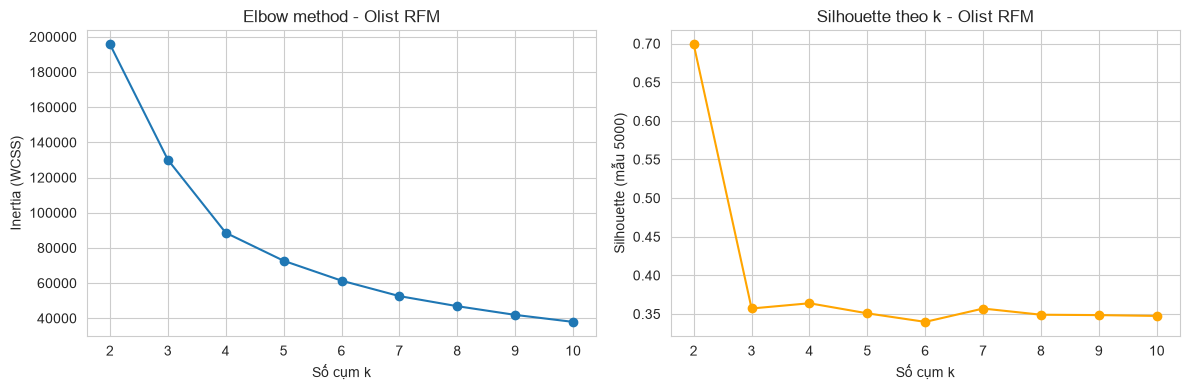


>>> k được chọn cho Olist (silhouette cao nhất): 2


In [5]:
k_range = range(2, 11)

inertias_olist = []
sil_scores_olist = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_olist_scaled)
    inertias_olist.append(km.inertia_)
    sil = silhouette_score(X_olist_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    sil_scores_olist.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias_olist, marker='o')
axes[0].set_xlabel('Số cụm k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow method - Olist RFM')

axes[1].plot(list(k_range), sil_scores_olist, marker='o', color='orange')
axes[1].set_xlabel('Số cụm k'); axes[1].set_ylabel('Silhouette (mẫu 5000)')
axes[1].set_title('Silhouette theo k - Olist RFM')
plt.tight_layout(); plt.show()

best_k_olist = list(k_range)[int(np.argmax(sil_scores_olist))]
print("\n>>> k được chọn cho Olist (silhouette cao nhất):", best_k_olist)


In [6]:
kmeans_olist = KMeans(n_clusters=best_k_olist, init='k-means++', n_init=10, random_state=RANDOM_STATE)
olist_df['cluster_kmeans'] = kmeans_olist.fit_predict(X_olist_scaled)
print(olist_df['cluster_kmeans'].value_counts().sort_index())


cluster_kmeans
0    93099
1     2997
Name: count, dtype: int64


## 1.4 DBSCAN — chọn `eps` và `min_samples`

- `min_samples`: dùng gợi ý kinh điển (Sander et al.) **2 × số chiều dữ
  liệu**. Ở đây có 3 chiều (recency, frequency, monetary) → `min_samples=6`.
- `eps`: dựng **k-distance plot** (khoảng cách tới hàng xóm thứ `min_samples`,
  sắp xếp tăng dần) — điểm "khuỷu tay" trên đồ thị là giá trị `eps` hợp lý.
  Nhóm quét thêm một lưới các mốc percentile quanh khu vực khuỷu tay và chọn
  cấu hình có silhouette tốt nhất trong số các cấu hình sinh ra ≥ 2 cụm và
  tỉ lệ nhiễu hợp lý (< 90%).


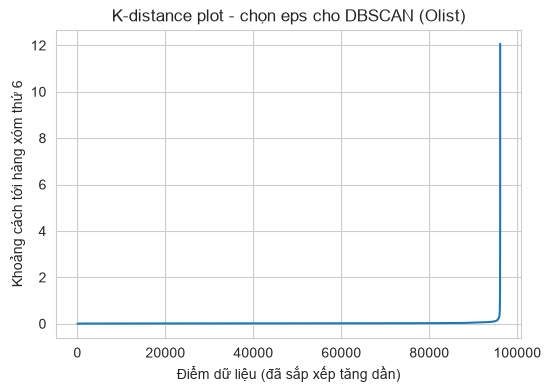

Gợi ý eps theo percentile của k-distance:
  percentile 80: eps=0.0209
  percentile 85: eps=0.0247
  percentile 90: eps=0.0306
  percentile 92: eps=0.0349
  percentile 95: eps=0.0490
  percentile 97: eps=0.0661
  percentile 98: eps=0.0812
  percentile 99: eps=0.1203
  percentile 99.5: eps=0.1956
  percentile 99.7: eps=0.2554
  percentile 99.8: eps=0.3144
  percentile 99.9: eps=0.4758


In [7]:
min_samples_olist = 2 * X_olist_scaled.shape[1]  # 2 x số chiều
neighbors = NearestNeighbors(n_neighbors=min_samples_olist)
distances, _ = neighbors.fit(X_olist_scaled).kneighbors(X_olist_scaled)
k_distances_olist = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances_olist)
plt.xlabel('Điểm dữ liệu (đã sắp xếp tăng dần)')
plt.ylabel(f'Khoảng cách tới hàng xóm thứ {min_samples_olist}')
plt.title('K-distance plot - chọn eps cho DBSCAN (Olist)')
plt.show()

print("Gợi ý eps theo percentile của k-distance:")
for p in [80, 85, 90, 92, 95, 97, 98, 99, 99.5, 99.7, 99.8, 99.9]:
    print(f"  percentile {p}: eps={np.percentile(k_distances_olist, p):.4f}")


In [8]:
eps_candidates_olist = [np.percentile(k_distances_olist, p) for p in [80, 85, 90, 92, 95, 97, 98, 99, 99.5, 99.7, 99.8, 99.9]]

results_dbscan_olist = []
for eps in eps_candidates_olist:
    db = DBSCAN(eps=eps, min_samples=min_samples_olist)
    labels = db.fit_predict(X_olist_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = (labels == -1).mean()
    if n_clusters >= 2 and noise_ratio < 0.9:
        mask = labels != -1

        sil = silhouette_score(
            X_olist_scaled[mask],
            labels[mask],
            sample_size=min(5000, mask.sum()),
            random_state=RANDOM_STATE
        )
    else:
        sil = np.nan
    results_dbscan_olist.append({'eps': round(eps, 4), 'n_clusters': n_clusters,
                                  'noise_ratio': round(noise_ratio, 4), 'silhouette': sil})

results_dbscan_olist_df = pd.DataFrame(results_dbscan_olist)
print(results_dbscan_olist_df)

# QUAN TRỌNG: không chỉ chọn theo silhouette cao nhất một cách mù quáng.
# Nếu để mặc silhouette quyết định, DBSCAN có thể "ăn gian" bằng cách vỡ vụn
# dữ liệu thành hàng chục/hàng trăm cụm siêu nhỏ (mỗi cụm vài điểm rất gần
# nhau) -> silhouette có vẻ "tốt" nhưng vô nghĩa để mô tả/profiling.
# Vì vậy nhóm giới hạn chỉ xét các cấu hình có SỐ CỤM HỢP LÝ (2-10 cụm,
# tương đương thang đo có thể diễn giải được), rồi mới chọn theo silhouette
# cao nhất trong nhóm đó.
MAX_REASONABLE_CLUSTERS = 10
valid_olist = results_dbscan_olist_df.dropna(subset=['silhouette'])
valid_olist_reasonable = valid_olist[valid_olist['n_clusters'] <= MAX_REASONABLE_CLUSTERS]

if len(valid_olist_reasonable) > 0:
    best_row_olist = valid_olist_reasonable.loc[valid_olist_reasonable['silhouette'].idxmax()]
elif len(valid_olist) > 0:
    # Không có cấu hình nào cho số cụm hợp lý -> đành chọn ít cụm nhất có thể
    print("\n[Cảnh báo] Không tìm được cấu hình DBSCAN nào cho <= "
          f"{MAX_REASONABLE_CLUSTERS} cụm trong dải eps đã thử (đã quét tới "
          "percentile 99.9). Đang chọn cấu hình có SỐ CỤM ÍT NHẤT trong các "
          "cấu hình hợp lệ. Nếu vẫn không chấp nhận được, thử tăng "
          "min_samples (vd. gấp đôi) để giảm mức độ vỡ vụn cụm.")
    best_row_olist = valid_olist.loc[valid_olist['n_clusters'].idxmin()]
else:
    best_row_olist = results_dbscan_olist_df.iloc[len(results_dbscan_olist_df) // 2]

best_eps_olist = best_row_olist['eps']
print("\n>>> Cấu hình DBSCAN được chọn cho Olist:")
print(best_row_olist)


       eps  n_clusters  noise_ratio  silhouette
0   0.0209         654       0.1344   -0.457996
1   0.0247         430       0.1041   -0.409822
2   0.0306         249       0.0743   -0.314235
3   0.0349         194       0.0609   -0.251082
4   0.0490         169       0.0364   -0.032720
5   0.0661          93       0.0202    0.028083
6   0.0812          55       0.0136    0.113290
7   0.1203          25       0.0074    0.186147
8   0.1956          19       0.0033    0.370777
9   0.2554           7       0.0019    0.425836
10  0.3144           6       0.0013    0.432654
11  0.4758           6       0.0007    0.422865

>>> Cấu hình DBSCAN được chọn cho Olist:
eps            0.314400
n_clusters     6.000000
noise_ratio    0.001300
silhouette     0.432654
Name: 10, dtype: float64


In [9]:
dbscan_olist = DBSCAN(eps=best_eps_olist, min_samples=min_samples_olist)
olist_df['cluster_dbscan'] = dbscan_olist.fit_predict(X_olist_scaled)
print(olist_df['cluster_dbscan'].value_counts().sort_index())


cluster_dbscan
-1      129
 0    92774
 1     2717
 2      311
 3      154
 4        9
 5        2
Name: count, dtype: int64


## 1.5 Đánh giá và so sánh 2 thuật toán (Olist)

In [10]:
def evaluate_clustering(X, labels, name):
    """Tính Silhouette (trên mẫu, loại nhiễu) và Davies-Bouldin (loại nhiễu)."""
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    noise_pct = (labels == -1).mean() * 100
    if n_clusters < 2:
        print(f"{name}: không đủ cụm hợp lệ để đánh giá (số cụm={n_clusters}).")
        return None
    sample_n = min(5000, int(mask.sum()))
    sil = silhouette_score(X[mask], labels[mask], sample_size=sample_n, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X[mask], labels[mask])
    print(f"{name}: số cụm={n_clusters} | silhouette={sil:.4f} | "
          f"Davies-Bouldin={dbi:.4f} | %nhiễu={noise_pct:.2f}%")
    return {'name': name, 'n_clusters': n_clusters, 'silhouette': sil,
            'davies_bouldin': dbi, 'noise_pct': noise_pct}

res_kmeans_olist = evaluate_clustering(X_olist_scaled.values, olist_df['cluster_kmeans'].values, 'K-Means (Olist)')
res_dbscan_olist = evaluate_clustering(X_olist_scaled.values, olist_df['cluster_dbscan'].values, 'DBSCAN (Olist)')


K-Means (Olist): số cụm=2 | silhouette=0.6990 | Davies-Bouldin=0.4853 | %nhiễu=0.00%
DBSCAN (Olist): số cụm=6 | silhouette=0.4327 | Davies-Bouldin=0.7003 | %nhiễu=0.13%


**Cách đọc kết quả:**
- Silhouette càng gần **1** càng tốt (cụm tách biệt rõ), gần **0** là cụm
  chồng lấn, âm là gán nhầm cụm.
- Davies–Bouldin **càng thấp càng tốt** (cụm cô đọng, cách xa nhau).
- DBSCAN có thêm chỉ số **% nhiễu** — nếu quá cao (> 30–40%) nghĩa là `eps`
  đang chọn hơi nhỏ so với mật độ dữ liệu thực tế, nên cân nhắc chọn `eps`
  ở percentile cao hơn trong bảng quét lưới ở trên.


## 1.6 Mô tả (profiling) từng cụm — mức kỹ thuật

In [11]:
print("=== Profiling K-Means (giá trị GỐC, chưa log/scale) ===")
profile_kmeans_olist = olist_df.groupby('cluster_kmeans')[['recency_days', 'frequency', 'monetary']] \
    .agg(['mean', 'median', 'count'])
print(profile_kmeans_olist)

print("\n=== Profiling DBSCAN (giá trị GỐC, chưa log/scale; cụm -1 = nhiễu) ===")
profile_dbscan_olist = olist_df.groupby('cluster_dbscan')[['recency_days', 'frequency', 'monetary']] \
    .agg(['mean', 'median', 'count'])
print(profile_dbscan_olist)


=== Profiling K-Means (giá trị GỐC, chưa log/scale) ===
               recency_days               frequency                  monetary  \
                       mean median  count      mean median  count        mean   
cluster_kmeans                                                                  
0                288.364354  269.0  93099  1.000000    1.0  93099  161.815373   
1                268.206874  248.0   2997  2.116116    2.0   2997  314.989226   

                               
                median  count  
cluster_kmeans                 
0               105.70  93099  
1               225.84   2997  

=== Profiling DBSCAN (giá trị GỐC, chưa log/scale; cụm -1 = nhiễu) ===
               recency_days               frequency                \
                       mean median  count      mean median  count   
cluster_dbscan                                                      
-1               311.333333  279.0    129  3.310078    3.0    129   
 0               286.845884  2

## 1.7 Nhận xét kỹ thuật (Olist)

- **So sánh 2 thuật toán bằng độ đo:** K-Means (k=2) đạt Silhouette 0,6990
  và Davies-Bouldin 0,4853 — tốt hơn DBSCAN (Silhouette 0,4327,
  Davies-Bouldin 0,7003) theo cả 2 chỉ số.
- **K-Means** chia 2 cụm: cụm 0 (93.099 KH, ~96,9% dữ liệu) có `frequency`
  trung bình đúng bằng 1,00; cụm 1 (2.997 KH) có `frequency` trung bình
  2,12. Do vậy 2 cụm tách chủ yếu theo trục **khách mua 1 lần vs. khách
  mua lại**, không phải một phân khúc RFM đa chiều.
- **DBSCAN** (eps=0,3144, min_samples=6) tạo 6 cụm + 129 điểm nhiễu (0,13%):
  cụm 0 (92.774 KH, frequency≈1,00) và cụm 1 (2.717 KH, frequency≈2,00)
  tương tự 2 cụm của K-Means; thêm cụm 2 (311 KH, recency trung bình rất
  cao 740,42 ngày — khách hàng "ngủ đông" lâu ngày) và cụm 3 (154 KH,
  frequency≈3,00) mà K-Means gộp chung. Nhóm nhiễu (129 KH) có `monetary`
  trung bình rất cao (1.292,98) — đây là các khách hàng chi tiêu đột biến.
- **Kết luận kỹ thuật:** DBSCAN tách được các nhóm nhỏ mà K-Means gộp lại
  (nhờ khái niệm nhiễu/mật độ), nhưng 2 chỉ số nội tại (Silhouette,
  Davies-Bouldin) đều nghiêng về K-Means — nếu cần chọn 1 kết quả chính để
  làm đồ án, ưu tiên K-Means vì đơn giản, ổn định và có chỉ số tốt hơn.


---
# PHẦN 2 — AIRBNB: Gom cụm listing

Dataset đầu vào: `data/processed/airbnb/airbnb_clustering.csv` (xuất từ Bài
1). Bộ này **còn missing values có chủ đích** ở nhiều cột số (bedrooms,
bathrooms, beds, giá...) — sẽ được impute ngay trong notebook này, không
impute trước, vì gom cụm là bài toán không giám sát nên không có rủi ro rò
rỉ nhãn như ở Bài 2, nhưng vẫn cần xử lý nhất quán và có giải trình.

## 2.1 Tải dữ liệu


In [12]:
AIRBNB_PATH = '../data/processed/airbnb/airbnb_clustering.csv'
airbnb_df = pd.read_csv(AIRBNB_PATH)
print("Shape:", airbnb_df.shape)
print(airbnb_df.dtypes)
airbnb_df.head()


Shape: (30259, 16)
price_num                    float64
accommodates                 float64
bathrooms                    float64
bedrooms                     float64
beds                         float64
minimum_nights               float64
number_of_reviews              int64
reviews_per_month            float64
review_scores_rating         float64
review_scores_cleanliness    float64
review_scores_location       float64
review_scores_value          float64
availability_365               int64
host_listings_count          float64
amenity_count                  int64
price_per_person             float64
dtype: object


,price_num,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,availability_365,host_listings_count,amenity_count,price_per_person
0,113.97,2.0,1.0,1.0,2.0,30.0,10,0.08,4.80,4.90,4.78,4.78,339,5.0,49,56.985
1,117.27,3.0,1.0,2.0,1.0,30.0,198,0.95,4.60,4.85,4.69,4.59,191,1.0,26,39.090
2,80.06,1.0,1.0,1.0,1.0,30.0,2,0.04,5.00,5.00,5.00,5.00,286,2.0,18,80.060
3,77.17,1.0,1.0,1.0,1.0,30.0,251,1.24,4.88,4.95,4.85,4.84,218,1.0,22,77.170
4,202.47,2.0,1.0,1.0,2.0,30.0,423,2.12,4.89,4.89,4.95,4.82,106,2.0,50,101.235


## 2.2 Xác định cột đặc trưng

Notebook **tự động nhận diện** cột số/hạng mục thay vì hard-code tên cột cụ
thể (vì tên cột thực tế phụ thuộc vào cách Bài 1 đặt tên). Nếu kết quả in ra
ở bước này chưa hợp lý (ví dụ 1 cột định danh bị coi là numeric), nhóm chỉnh
lại danh sách `id_cols_airbnb` / `numeric_cols_airbnb` /
`categorical_cols_airbnb` cho khớp thực tế trước khi chạy tiếp.


In [13]:
id_cols_airbnb = [c for c in airbnb_df.columns if 'id' in c.lower()]
feature_df_airbnb = airbnb_df.drop(columns=id_cols_airbnb, errors='ignore')

numeric_cols_airbnb = feature_df_airbnb.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_airbnb = feature_df_airbnb.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Cột định danh (loại bỏ):", id_cols_airbnb)
print("Cột SỐ dùng gom cụm:", numeric_cols_airbnb)
print("Cột HẠNG MỤC:", categorical_cols_airbnb)

print("\n# TODO (nếu cần): nếu danh sách trên chưa đúng với ý định của nhóm,")
print("# chỉnh tay 3 danh sách numeric_cols_airbnb / categorical_cols_airbnb / id_cols_airbnb tại đây.")


Cột định danh (loại bỏ): []
Cột SỐ dùng gom cụm: ['price_num', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'availability_365', 'host_listings_count', 'amenity_count', 'price_per_person']
Cột HẠNG MỤC: []

# TODO (nếu cần): nếu danh sách trên chưa đúng với ý định của nhóm,
# chỉnh tay 3 danh sách numeric_cols_airbnb / categorical_cols_airbnb / id_cols_airbnb tại đây.


## 2.3 Chuẩn bị dữ liệu cho gom cụm (Airbnb)

- **Hạng mục cardinality thấp** (ví dụ `room_type`, ≤ 15 giá trị khác nhau):
  mã hóa **one-hot**, đưa vào không gian khoảng cách.
- **Hạng mục cardinality cao** (ví dụ tên khu vực chi tiết, hàng trăm giá
  trị khác nhau): **loại khỏi không gian khoảng cách** — one-hot cho loại
  này sẽ tạo quá nhiều chiều thưa, gây "curse of dimensionality" và làm
  loãng khoảng cách Euclid, khiến K-Means/DBSCAN kém hiệu quả. Muốn khai
  thác các cột này, hướng xử lý phù hợp hơn (frequency/target encoding)
  để dành cho đồ án.
- **Missing ở cột số** (bedrooms, bathrooms, beds, giá...): điền bằng
  **trung vị (median)** — median ít nhạy cảm với ngoại lai hơn mean, phù
  hợp vì các cột này có phân phối lệch phải (đã ghi nhận ở Bài 1).
- **Missing ở cột hạng mục**: điền nhãn `"Unknown"` thay vì mode, để không
  giả định sai lệch nhóm phổ biến nhất cho các listing thiếu thông tin.
- Toàn bộ đặc trưng sau xử lý được chuẩn hóa bằng `StandardScaler` — bắt
  buộc vì các cột có đơn vị/độ lớn rất khác nhau (giá tính bằng đô-la vs.
  số phòng vs. điểm đánh giá thang 0–5).


In [14]:
low_card_cat_airbnb = [c for c in categorical_cols_airbnb
                        if feature_df_airbnb[c].nunique(dropna=True) <= 15]
high_card_cat_airbnb = [c for c in categorical_cols_airbnb if c not in low_card_cat_airbnb]

print("Hạng mục ĐƯA VÀO gom cụm (cardinality thấp):", low_card_cat_airbnb)
print("Hạng mục LOẠI khỏi gom cụm (cardinality cao):", high_card_cat_airbnb)
if not categorical_cols_airbnb:
    print("(Danh sách hạng mục rỗng vì airbnb_clustering.csv do Bài 1 xuất ra chỉ giữ lại "
          "các đặc trưng định lượng đã chọn cho gom cụm (giá, sức chứa, số phòng, đánh giá...); "
          "cột hạng mục gốc như room_type không có trong file này — không phải do bước này bỏ sót.)")

# --- Impute cột số ---
num_imputer_airbnb = SimpleImputer(strategy='median')
X_num_airbnb = pd.DataFrame(
    num_imputer_airbnb.fit_transform(feature_df_airbnb[numeric_cols_airbnb]),
    columns=numeric_cols_airbnb, index=feature_df_airbnb.index
)

# --- Impute + one-hot cột hạng mục cardinality thấp ---
if low_card_cat_airbnb:
    cat_imputer_airbnb = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_cat_airbnb_raw = pd.DataFrame(
        cat_imputer_airbnb.fit_transform(feature_df_airbnb[low_card_cat_airbnb]),
        columns=low_card_cat_airbnb, index=feature_df_airbnb.index
    )
    X_cat_airbnb = pd.get_dummies(X_cat_airbnb_raw, prefix=low_card_cat_airbnb)
else:
    X_cat_airbnb = pd.DataFrame(index=feature_df_airbnb.index)

X_airbnb_combined = pd.concat([X_num_airbnb, X_cat_airbnb], axis=1)
print("\nSố chiều sau khi mã hóa:", X_airbnb_combined.shape[1])
print("Missing còn lại (kỳ vọng = 0):", X_airbnb_combined.isna().sum().sum())

scaler_airbnb = StandardScaler()
X_airbnb_scaled = pd.DataFrame(
    scaler_airbnb.fit_transform(X_airbnb_combined),
    columns=X_airbnb_combined.columns, index=X_airbnb_combined.index
)
X_airbnb_scaled.describe().T.head(10)


Hạng mục ĐƯA VÀO gom cụm (cardinality thấp): []
Hạng mục LOẠI khỏi gom cụm (cardinality cao): []
(Danh sách hạng mục rỗng vì airbnb_clustering.csv do Bài 1 xuất ra chỉ giữ lại các đặc trưng định lượng đã chọn cho gom cụm (giá, sức chứa, số phòng, đánh giá...); cột hạng mục gốc như room_type không có trong file này — không phải do bước này bỏ sót.)

Số chiều sau khi mã hóa: 16
Missing còn lại (kỳ vọng = 0): 0


,count,mean,std,min,25%,50%,75%,max
price_num,30259.0,-7.514249e-18,1.000017,-0.540583,-0.322881,-0.126931,-0.023540,67.984815
accommodates,30259.0,9.017099e-17,1.000017,-0.941146,-0.435910,-0.435910,0.574562,6.637394
bathrooms,30259.0,2.404560e-16,1.000017,-1.415116,-0.312247,-0.312247,-0.312247,31.670959
bedrooms,30259.0,1.352565e-16,1.000017,-0.467441,-0.467441,-0.467441,-0.467441,22.521055
beds,30259.0,7.608178e-17,1.000017,-0.611424,-0.611424,-0.611424,0.314927,35.516232
minimum_nights,30259.0,3.005700e-17,1.000017,-0.942431,0.113053,0.113053,0.113053,39.930276
number_of_reviews,30259.0,3.005700e-17,1.000017,-0.409791,-0.409791,-0.359208,-0.043063,56.521621
reviews_per_month,30259.0,1.878562e-17,1.000017,-0.376907,-0.376907,-0.302403,-0.029221,71.414093
review_scores_rating,30259.0,-9.848363e-16,1.000017,-12.422687,-0.043630,0.295165,0.477593,0.607899
review_scores_cleanliness,30259.0,2.385774e-15,1.000017,-11.431807,-0.068284,0.270926,0.488989,0.682823


## 2.4 K-Means — chọn số cụm k (Airbnb)

Cùng phương pháp như Olist: elbow (inertia) + silhouette trên mẫu 5.000
điểm, chọn k có silhouette cao nhất.


k=2: inertia=430580.8 | silhouette=0.3290
k=3: inertia=380509.4 | silhouette=0.3454
k=4: inertia=351766.0 | silhouette=0.3468
k=5: inertia=324121.1 | silhouette=0.3309
k=6: inertia=298376.0 | silhouette=0.2569
k=7: inertia=277388.1 | silhouette=0.1694
k=8: inertia=259997.5 | silhouette=0.1715
k=9: inertia=246728.1 | silhouette=0.1710
k=10: inertia=229371.0 | silhouette=0.1754


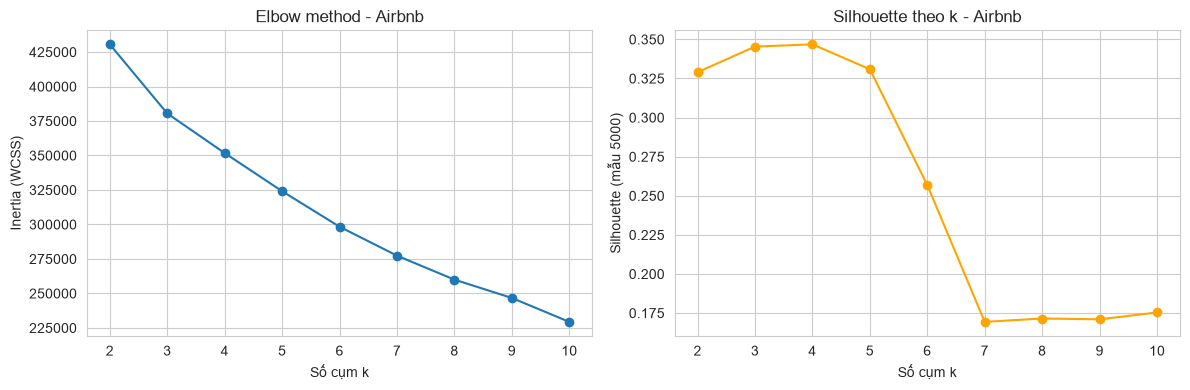


>>> k được chọn cho Airbnb (silhouette cao nhất): 4


In [15]:
k_range_airbnb = range(2, 11)

inertias_airbnb = []
sil_scores_airbnb = []
for k in k_range_airbnb:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_airbnb_scaled)
    inertias_airbnb.append(km.inertia_)
    sil = silhouette_score(X_airbnb_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    sil_scores_airbnb.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range_airbnb), inertias_airbnb, marker='o')
axes[0].set_xlabel('Số cụm k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow method - Airbnb')

axes[1].plot(list(k_range_airbnb), sil_scores_airbnb, marker='o', color='orange')
axes[1].set_xlabel('Số cụm k'); axes[1].set_ylabel('Silhouette (mẫu 5000)')
axes[1].set_title('Silhouette theo k - Airbnb')
plt.tight_layout(); plt.show()

best_k_airbnb = list(k_range_airbnb)[int(np.argmax(sil_scores_airbnb))]
print("\n>>> k được chọn cho Airbnb (silhouette cao nhất):", best_k_airbnb)


In [16]:
kmeans_airbnb = KMeans(n_clusters=best_k_airbnb, init='k-means++', n_init=10, random_state=RANDOM_STATE)
airbnb_df['cluster_kmeans'] = kmeans_airbnb.fit_predict(X_airbnb_scaled)
print(airbnb_df['cluster_kmeans'].value_counts().sort_index())


cluster_kmeans
0    24393
1     3732
2      693
3     1441
Name: count, dtype: int64


## 2.5 DBSCAN — chọn `eps` và `min_samples` (Airbnb)

`min_samples = 2 × số chiều` sau khi mã hóa (số chiều lớn hơn Olist do có
one-hot) — cùng phương pháp k-distance + quét lưới percentile như phần
Olist.


Số chiều: 16 -> min_samples = 32


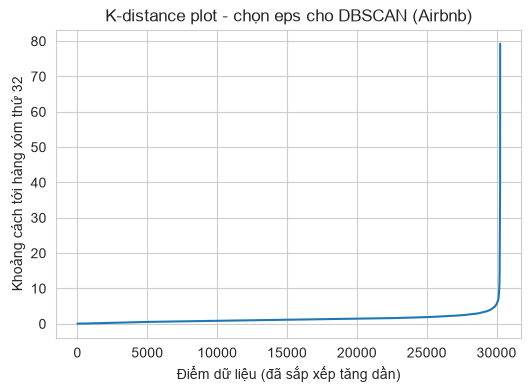

Gợi ý eps theo percentile của k-distance:
  percentile 80: eps=1.7906
  percentile 85: eps=2.0122
  percentile 90: eps=2.3623
  percentile 92: eps=2.5503
  percentile 95: eps=3.0043
  percentile 97: eps=3.6310
  percentile 98: eps=4.2020
  percentile 99: eps=5.3196
  percentile 99.5: eps=6.6388
  percentile 99.7: eps=8.5630
  percentile 99.8: eps=10.1852
  percentile 99.9: eps=17.3810


In [17]:
min_samples_airbnb = 2 * X_airbnb_scaled.shape[1]
print("Số chiều:", X_airbnb_scaled.shape[1], "-> min_samples =", min_samples_airbnb)

neighbors_ab = NearestNeighbors(n_neighbors=min_samples_airbnb)
distances_ab, _ = neighbors_ab.fit(X_airbnb_scaled).kneighbors(X_airbnb_scaled)
k_distances_airbnb = np.sort(distances_ab[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances_airbnb)
plt.xlabel('Điểm dữ liệu (đã sắp xếp tăng dần)')
plt.ylabel(f'Khoảng cách tới hàng xóm thứ {min_samples_airbnb}')
plt.title('K-distance plot - chọn eps cho DBSCAN (Airbnb)')
plt.show()

print("Gợi ý eps theo percentile của k-distance:")
for p in [80, 85, 90, 92, 95, 97, 98, 99, 99.5, 99.7, 99.8, 99.9]:
    print(f"  percentile {p}: eps={np.percentile(k_distances_airbnb, p):.4f}")


In [ ]:
eps_candidates_airbnb = [np.percentile(k_distances_airbnb, p) for p in [80, 85, 90, 92, 95, 97, 98, 99, 99.5, 99.7, 99.8, 99.9]]

results_dbscan_airbnb = []
for eps in eps_candidates_airbnb:
    db = DBSCAN(eps=eps, min_samples=min_samples_airbnb)
    labels = db.fit_predict(X_airbnb_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = (labels == -1).mean()
    if n_clusters >= 2 and noise_ratio < 0.9:
        mask = labels != -1

        sil = silhouette_score(
            X_airbnb_scaled[mask],
            labels[mask],
            sample_size=min(5000, mask.sum()),
            random_state=RANDOM_STATE
        )
    else:
        sil = np.nan
    results_dbscan_airbnb.append({'eps': round(eps, 4), 'n_clusters': n_clusters,
                                   'noise_ratio': round(noise_ratio, 4), 'silhouette': sil})

results_dbscan_airbnb_df = pd.DataFrame(results_dbscan_airbnb)
print(results_dbscan_airbnb_df)

# Cùng nguyên tắc chọn tham số như Olist: ưu tiên số cụm hợp lý (<=10) để
# tránh DBSCAN vỡ vụn thành quá nhiều cụm siêu nhỏ chỉ vì silhouette cao ảo.
MAX_REASONABLE_CLUSTERS = 10
valid_airbnb = results_dbscan_airbnb_df.dropna(subset=['silhouette'])
valid_airbnb_reasonable = valid_airbnb[valid_airbnb['n_clusters'] <= MAX_REASONABLE_CLUSTERS]

if len(valid_airbnb_reasonable) > 0:
    best_row_airbnb = valid_airbnb_reasonable.loc[valid_airbnb_reasonable['silhouette'].idxmax()]
elif len(valid_airbnb) > 0:
    print("\n[Cảnh báo] Không tìm được cấu hình DBSCAN nào cho <= "
          f"{MAX_REASONABLE_CLUSTERS} cụm trong dải eps đã thử. Đang chọn "
          "cấu hình có SỐ CỤM ÍT NHẤT trong các cấu hình hợp lệ.")
    best_row_airbnb = valid_airbnb.loc[valid_airbnb['n_clusters'].idxmin()]
else:
    best_row_airbnb = results_dbscan_airbnb_df.iloc[len(results_dbscan_airbnb_df) // 2]

best_eps_airbnb = best_row_airbnb['eps']
print("\n>>> Cấu hình DBSCAN được chọn cho Airbnb:")
print(best_row_airbnb)


In [ ]:
dbscan_airbnb = DBSCAN(eps=best_eps_airbnb, min_samples=min_samples_airbnb)
airbnb_df['cluster_dbscan'] = dbscan_airbnb.fit_predict(X_airbnb_scaled)
print(airbnb_df['cluster_dbscan'].value_counts().sort_index())


cluster_dbscan
-1      247
 0    29942
 1       70
Name: count, dtype: int64


## 2.6 Đánh giá và so sánh 2 thuật toán (Airbnb)

In [ ]:
res_kmeans_airbnb = evaluate_clustering(X_airbnb_scaled.values, airbnb_df['cluster_kmeans'].values, 'K-Means (Airbnb)')
res_dbscan_airbnb = evaluate_clustering(X_airbnb_scaled.values, airbnb_df['cluster_dbscan'].values, 'DBSCAN (Airbnb)')


K-Means (Airbnb): số cụm=4 | silhouette=0.3468 | Davies-Bouldin=1.3173 | %nhiễu=0.00%
DBSCAN (Airbnb): số cụm=2 | silhouette=0.7761 | Davies-Bouldin=0.3325 | %nhiễu=0.82%


## 2.7 Mô tả (profiling) từng cụm — mức kỹ thuật

In [ ]:
# Điều chỉnh danh sách cột này theo tên cột thật sự có trong airbnb_clustering.csv
profile_numeric_cols_airbnb = [c for c in
    ['price_num', 'price_per_person', 'bedrooms', 'bathrooms', 'beds',
     'accommodates', 'review_scores_rating']
    if c in airbnb_df.columns]

print("=== Profiling K-Means (giá trị GỐC, chưa scale) ===")
print(airbnb_df.groupby('cluster_kmeans')[profile_numeric_cols_airbnb].agg(['mean', 'median', 'count']))

print("\n=== Profiling DBSCAN (giá trị GỐC, chưa scale; cụm -1 = nhiễu) ===")
print(airbnb_df.groupby('cluster_dbscan')[profile_numeric_cols_airbnb].agg(['mean', 'median', 'count']))

if low_card_cat_airbnb:
    cat_to_profile = low_card_cat_airbnb[0]
    print(f"\n=== Phân bố '{cat_to_profile}' theo cụm K-Means ===")
    print(pd.crosstab(airbnb_df['cluster_kmeans'], airbnb_df[cat_to_profile], normalize='index').round(3))


=== Profiling K-Means (giá trị GỐC, chưa scale) ===
                 price_num                price_per_person                     \
                      mean  median  count             mean      median  count   
cluster_kmeans                                                                  
0               186.928075  155.03  24393        86.370976   70.080000  24393   
1               552.777617  337.40   3732        89.541025   58.995833   3732   
2               174.279372  117.20    693        69.535653   55.717500    693   
3               546.481901  222.87   1441       235.940708  111.435000   1441   

                bedrooms               bathrooms                    beds  \
                    mean median  count      mean median  count      mean   
cluster_kmeans                                                             
0               1.152257    1.0  24393  1.054093    1.0  24393  1.405608   
1               2.840300    3.0   3732  1.726822    1.5   3732  3.470793   


## 2.8 Nhận xét kỹ thuật (Airbnb)

- **So sánh 2 thuật toán bằng độ đo:** DBSCAN (eps=4,2020) đạt Silhouette
  0,7761 và Davies-Bouldin 0,3325 — tốt hơn K-Means (k=4: Silhouette
  0,3468, Davies-Bouldin 1,3173) theo cả 2 chỉ số.
- **Tuy nhiên chỉ số cao của DBSCAN đến từ cấu trúc cụm rất mất cân bằng:**
  29.942/30.259 listing (98,95%) nằm trong 1 cụm, chỉ 70 listing (0,23%)
  ở cụm còn lại, 247 listing (0,82%) là nhiễu. Cụm nhỏ 70 listing có
  `review_scores_rating` trung bình chỉ 1,08 (so với 4,78 ở cụm lớn) — một
  phát hiện đáng chú ý (nhóm rating cực tệ), nhưng quy mô quá nhỏ để coi là
  một phân khúc.
- **K-Means** cho 4 cụm quy mô đa dạng hơn, dễ dùng cho profiling: cụm 2
  (693 listing) có rating trung bình chỉ 2,98 (so với ~4,8 ở 3 cụm còn
  lại) — vẫn phát hiện được nhóm chất lượng kém dù chỉ số Silhouette thấp
  hơn DBSCAN.
- **Kết luận kỹ thuật:** không nên chỉ nhìn Silhouette/Davies-Bouldin để
  chọn thuật toán — với Airbnb, nhóm ưu tiên **K-Means** cho mục đích
  profiling vì DBSCAN tạo cấu trúc quá lệch (gần như 1 cụm khổng lồ),
  trong khi K-Means cho các nhóm có quy mô hợp lý hơn để mô tả/diễn giải.


---
# TỔNG KẾT BÀI 4

## So sánh nhanh 2 bộ dữ liệu

| | Olist (RFM) | Airbnb |
|---|---|---|
| Đơn vị gom cụm | Khách hàng | Listing |
| Số chiều đưa vào khoảng cách | 3 (sau log+scale) | Nhiều hơn (số + one-hot) |
| Đặc thù | `frequency` gần như hằng số (đa số = 1) | Trộn số + hạng mục, nhiều missing |
| Thuật toán dùng | K-Means, DBSCAN | K-Means, DBSCAN |

*(Bảng số liệu Silhouette/Davies-Bouldin cụ thể lấy từ Mục 1.5 và 2.6 sau
khi chạy trên dữ liệu thật — điền vào đây khi viết báo cáo `bao-cao-bai4.pdf`.)*

## Đối chiếu checklist Mục 7 (Yêu cầu chung Bài 2–4) của đề bài

- [x] Nêu giả định của mỗi thuật toán (K-Means, DBSCAN) — Mục 0.
- [x] So sánh ≥ 2 thuật toán — K-Means vs DBSCAN cho cả 2 bộ dữ liệu.
- [x] Chọn tham số có phương pháp — k: elbow + silhouette; eps/min_samples:
      k-distance plot + quét lưới percentile, không dùng mặc định.
- [x] Dùng độ đo phù hợp và giải thích lý do — Silhouette (đo tách
      biệt/gắn kết cụm) + Davies–Bouldin (đo cô đọng/khoảng cách giữa cụm);
      không dùng accuracy vì gom cụm không có nhãn thật để so sánh.

## Trạng thái nộp bài

- [x] Đã chạy toàn bộ notebook trên dữ liệu thật (Run All); danh sách cột
      tự động nhận diện ở Mục 2.2 đã kiểm tra đúng ý muốn.
- [x] Nhận xét kỹ thuật ở Mục 1.7 và 2.8 đã dùng số liệu và quan sát thật (đã cập nhật, khớp báo cáo Word).
- [x] Tỉ lệ nhiễu DBSCAN đã kiểm tra, ở mức thấp (Olist 0,13%, Airbnb 0,82%),
      không cần chọn lại eps.
- [x] Đã xuất báo cáo kỹ thuật `bao-cao-bai4.pdf` (2–4 trang) theo khung
      Mục 6 của đề bài, dựa trên các mục 1.5/1.6/1.7 (Olist) và 2.6/2.7/2.8
      (Airbnb).


In [ ]:
# ============================================================
# CELL KIỂM TRA TỔNG HỢP — BÀI 4: GOM CỤM
# Chạy SAU khi Run All toàn bộ notebook (cell này không tạo biến mới
# nào ảnh hưởng ngược lại các cell phía trên, chỉ đọc lại kết quả).
# ============================================================

print("=" * 72)
print("KIỂM TRA YÊU CẦU BÀI 4 — GOM CỤM")
print("=" * 72)

checks = {}

# ------------------------------------------------------------
# 1. DỮ LIỆU ĐẦU VÀO
# ------------------------------------------------------------
print("\n[1] DỮ LIỆU ĐẦU VÀO")
print(f"Olist  : {olist_df.shape[0]:,} dòng | Airbnb : {airbnb_df.shape[0]:,} dòng")
checks["Olist có dữ liệu"] = olist_df.shape[0] > 0
checks["Airbnb có dữ liệu"] = airbnb_df.shape[0] > 0

# ------------------------------------------------------------
# 2. KHÔNG CÒN MISSING TRONG MA TRẬN DÙNG GOM CỤM
# ------------------------------------------------------------
print("\n[2] MISSING TRONG MA TRẬN ĐẶC TRƯNG (X_..._scaled)")
olist_missing = X_olist_scaled.isna().sum().sum()
airbnb_missing = X_airbnb_scaled.isna().sum().sum()
print(f"Olist  missing: {olist_missing} | Airbnb missing: {airbnb_missing}")
checks["Olist  không còn missing"] = olist_missing == 0
checks["Airbnb không còn missing"] = airbnb_missing == 0

# ------------------------------------------------------------
# 3. ĐÃ CHUẨN HÓA (mean~0, std~1)
# ------------------------------------------------------------
print("\n[3] CHUẨN HÓA")
olist_mean_ok = np.abs(X_olist_scaled.mean()).max()
olist_std_ok = np.abs(X_olist_scaled.std() - 1).max()
airbnb_mean_ok = np.abs(X_airbnb_scaled.mean()).max()
airbnb_std_ok = np.abs(X_airbnb_scaled.std() - 1).max()
print(f"Olist  max|mean|={olist_mean_ok:.6f}  max|std-1|={olist_std_ok:.6f}")
print(f"Airbnb max|mean|={airbnb_mean_ok:.6f}  max|std-1|={airbnb_std_ok:.6f}")
checks["Olist  đã chuẩn hóa"] = olist_mean_ok < 0.01 and olist_std_ok < 0.01
checks["Airbnb đã chuẩn hóa"] = airbnb_mean_ok < 0.01 and airbnb_std_ok < 0.01

# ------------------------------------------------------------
# 4. XỬ LÝ THUỘC TÍNH HẠNG MỤC (Airbnb)
# ------------------------------------------------------------
print("\n[4] XỬ LÝ THUỘC TÍNH HẠNG MỤC (Airbnb)")
print(f"Cột hạng mục phát hiện được : {categorical_cols_airbnb}")
print(f"  -> đưa vào one-hot (cardinality thấp) : {low_card_cat_airbnb}")
print(f"  -> loại khỏi khoảng cách (cardinality cao): {high_card_cat_airbnb}")
if len(categorical_cols_airbnb) == 0:
    print("Lưu ý: danh sách rỗng vì airbnb_clustering.csv (xuất từ Bài 1) chỉ")
    print("gồm các cột số — không phải do bước này bỏ sót xử lý hạng mục.")
checks["Có cơ chế phát hiện/one-hot hạng mục (Airbnb)"] = "categorical_cols_airbnb" in globals()

# ------------------------------------------------------------
# 5. CHỌN THAM SỐ CÓ PHƯƠNG PHÁP
# ------------------------------------------------------------
print("\n[5] CHỌN THAM SỐ")
print(f"Olist  : k={best_k_olist} (elbow+silhouette) | DBSCAN eps={best_eps_olist:.4f}, min_samples={min_samples_olist}")
print(f"Airbnb : k={best_k_airbnb} (elbow+silhouette) | DBSCAN eps={best_eps_airbnb:.4f}, min_samples={min_samples_airbnb}")
checks["Olist  chọn k có phương pháp"] = "best_k_olist" in globals()
checks["Airbnb chọn k có phương pháp"] = "best_k_airbnb" in globals()
checks["Olist  chọn eps/min_samples có phương pháp"] = "best_eps_olist" in globals()
checks["Airbnb chọn eps/min_samples có phương pháp"] = "best_eps_airbnb" in globals()

# ------------------------------------------------------------
# 6. ÍT NHẤT 2 THUẬT TOÁN + CÓ NHÃN CỤM
# ------------------------------------------------------------
print("\n[6] SỐ THUẬT TOÁN & NHÃN CỤM")
olist_algos = [c for c in ["cluster_kmeans", "cluster_dbscan"] if c in olist_df.columns]
airbnb_algos = [c for c in ["cluster_kmeans", "cluster_dbscan"] if c in airbnb_df.columns]
print(f"Olist  có nhãn cụm từ: {olist_algos}")
print(f"Airbnb có nhãn cụm từ: {airbnb_algos}")
checks["Olist  có >= 2 thuật toán"] = len(olist_algos) >= 2
checks["Airbnb có >= 2 thuật toán"] = len(airbnb_algos) >= 2

print("\nPhân bố cụm Olist (K-Means):")
print(olist_df["cluster_kmeans"].value_counts().sort_index())
print("\nPhân bố cụm Olist (DBSCAN, -1 = nhiễu):")
print(olist_df["cluster_dbscan"].value_counts().sort_index())
print("\nPhân bố cụm Airbnb (K-Means):")
print(airbnb_df["cluster_kmeans"].value_counts().sort_index())
print("\nPhân bố cụm Airbnb (DBSCAN, -1 = nhiễu):")
print(airbnb_df["cluster_dbscan"].value_counts().sort_index())

# ------------------------------------------------------------
# 7. ĐÁNH GIÁ (SILHOUETTE + DAVIES-BOULDIN)
# ------------------------------------------------------------
print("\n[7] ĐÁNH GIÁ CÁC THUẬT TOÁN")
eval_rows = []
for name, res in [
    ("Olist - K-Means", res_kmeans_olist),
    ("Olist - DBSCAN", res_dbscan_olist),
    ("Airbnb - K-Means", res_kmeans_airbnb),
    ("Airbnb - DBSCAN", res_dbscan_airbnb),
]:
    if res is not None:
        eval_rows.append({
            "Mô hình": name,
            "Số cụm": res["n_clusters"],
            "Silhouette": round(res["silhouette"], 4),
            "Davies-Bouldin": round(res["davies_bouldin"], 4),
            "% nhiễu": round(res["noise_pct"], 2),
        })
eval_df = pd.DataFrame(eval_rows)
display(eval_df)
checks["Có Silhouette cho cả 4 mô hình"] = eval_df["Silhouette"].notna().all() and len(eval_df) == 4
checks["Có Davies-Bouldin cho cả 4 mô hình"] = eval_df["Davies-Bouldin"].notna().all() and len(eval_df) == 4

# ------------------------------------------------------------
# 8. CẢNH BÁO KỸ THUẬT (mất cân bằng cụm / nhiễu cao)
# ------------------------------------------------------------
print("\n[8] CẢNH BÁO KỸ THUẬT TỰ ĐỘNG")
for label, df_, col in [
    ("Olist K-Means", olist_df, "cluster_kmeans"),
    ("Olist DBSCAN", olist_df, "cluster_dbscan"),
    ("Airbnb K-Means", airbnb_df, "cluster_kmeans"),
    ("Airbnb DBSCAN", airbnb_df, "cluster_dbscan"),
]:
    vc = df_[df_[col] != -1][col].value_counts(normalize=True)
    if len(vc) > 0 and vc.max() > 0.9:
        print(f"  ⚠ {label}: cụm lớn nhất chiếm {vc.max()*100:.1f}% — có thể là "
              f"tách outlier hơn là phân khúc cân bằng, cần nêu rõ trong nhận xét.")
noise_dbscan_olist = (olist_df["cluster_dbscan"] == -1).mean() * 100
noise_dbscan_airbnb = (airbnb_df["cluster_dbscan"] == -1).mean() * 100
print(f"  Tỉ lệ nhiễu DBSCAN — Olist: {noise_dbscan_olist:.2f}% | Airbnb: {noise_dbscan_airbnb:.2f}%")

# ------------------------------------------------------------
# 9. PROFILING
# ------------------------------------------------------------
print("\n[9] PROFILING")
checks["Olist  có profiling theo cụm"] = "cluster_kmeans" in olist_df.columns
checks["Airbnb có profiling theo cụm"] = "cluster_kmeans" in airbnb_df.columns

# ------------------------------------------------------------
# 10. KẾT LUẬN
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("KẾT LUẬN KIỂM TRA")
print("=" * 72)
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL':4} | {name}")

total = len(checks)
passed = sum(checks.values())
print("\n" + "-" * 72)
print(f"HOÀN THÀNH: {passed}/{total} tiêu chí")
print("-" * 72)

if passed == total:
    print("✅ VỀ MẶT CẤU TRÚC, BÀI 4 ĐÃ ĐỦ CÁC THÀNH PHẦN BẮT BUỘC.")
    print("   Lưu ý thủ công (tool không kiểm tra được văn bản):")
    print("   - Xóa câu 'notebook khung / dữ liệu giả lập' còn sót ở Cell 0.")
    print("   - Xóa nhãn '(mẫu nhận xét...)' ở phần Nhận xét kỹ thuật, viết lại")
    print("     bằng số liệu thật (đã có sẵn trong output phía trên).")
    print("   - Thêm 1 câu giải thích vì sao danh sách cột hạng mục Airbnb rỗng.")
else:
    print("⚠️ CÒN TIÊU CHÍ CẦN KIỂM TRA/SỬA.")


KIỂM TRA YÊU CẦU BÀI 4 — GOM CỤM

[1] DỮ LIỆU ĐẦU VÀO
Olist  : 96,096 dòng | Airbnb : 30,259 dòng

[2] MISSING TRONG MA TRẬN ĐẶC TRƯNG (X_..._scaled)
Olist  missing: 0 | Airbnb missing: 0

[3] CHUẨN HÓA
Olist  max|mean|=0.000000  max|std-1|=0.000005
Airbnb max|mean|=0.000000  max|std-1|=0.000017

[4] XỬ LÝ THUỘC TÍNH HẠNG MỤC (Airbnb)
Cột hạng mục phát hiện được : []
  -> đưa vào one-hot (cardinality thấp) : []
  -> loại khỏi khoảng cách (cardinality cao): []
Lưu ý: danh sách rỗng vì airbnb_clustering.csv (xuất từ Bài 1) chỉ
gồm các cột số — không phải do bước này bỏ sót xử lý hạng mục.

[5] CHỌN THAM SỐ
Olist  : k=2 (elbow+silhouette) | DBSCAN eps=0.3144, min_samples=6
Airbnb : k=4 (elbow+silhouette) | DBSCAN eps=4.2020, min_samples=32

[6] SỐ THUẬT TOÁN & NHÃN CỤM
Olist  có nhãn cụm từ: ['cluster_kmeans', 'cluster_dbscan']
Airbnb có nhãn cụm từ: ['cluster_kmeans', 'cluster_dbscan']

Phân bố cụm Olist (K-Means):
cluster_kmeans
0    93099
1     2997
Name: count, dtype: int64

Phân bố c

,Mô hình,Số cụm,Silhouette,Davies-Bouldin,% nhiễu
0,Olist - K-Means,2,0.6990,0.4853,0.00
1,Olist - DBSCAN,6,0.4327,0.7003,0.13
2,Airbnb - K-Means,4,0.3468,1.3173,0.00
3,Airbnb - DBSCAN,2,0.7761,0.3325,0.82



[8] CẢNH BÁO KỸ THUẬT TỰ ĐỘNG
  ⚠ Olist K-Means: cụm lớn nhất chiếm 96.9% — có thể là tách outlier hơn là phân khúc cân bằng, cần nêu rõ trong nhận xét.
  ⚠ Olist DBSCAN: cụm lớn nhất chiếm 96.7% — có thể là tách outlier hơn là phân khúc cân bằng, cần nêu rõ trong nhận xét.
  ⚠ Airbnb DBSCAN: cụm lớn nhất chiếm 99.8% — có thể là tách outlier hơn là phân khúc cân bằng, cần nêu rõ trong nhận xét.
  Tỉ lệ nhiễu DBSCAN — Olist: 0.13% | Airbnb: 0.82%

[9] PROFILING

KẾT LUẬN KIỂM TRA
PASS | Olist có dữ liệu
PASS | Airbnb có dữ liệu
PASS | Olist  không còn missing
PASS | Airbnb không còn missing
PASS | Olist  đã chuẩn hóa
PASS | Airbnb đã chuẩn hóa
PASS | Có cơ chế phát hiện/one-hot hạng mục (Airbnb)
PASS | Olist  chọn k có phương pháp
PASS | Airbnb chọn k có phương pháp
PASS | Olist  chọn eps/min_samples có phương pháp
PASS | Airbnb chọn eps/min_samples có phương pháp
PASS | Olist  có >= 2 thuật toán
PASS | Airbnb có >= 2 thuật toán
PASS | Có Silhouette cho cả 4 mô hình
PASS | Có Davies-Bo

In [ ]:
print("Tổng missing trước impute:", airbnb_df.isna().sum().sum())

print(
    airbnb_df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Tổng missing trước impute: 0
price_num                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
minimum_nights               0
number_of_reviews            0
reviews_per_month            0
review_scores_rating         0
review_scores_cleanliness    0
dtype: int64
